# Exploratory Data Analysis — Heart Disease Dataset

This notebook focuses purely on understanding the dataset: distributions, relationships between features and the target, and correlations. Model training happens separately in `model_training.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
df = pd.read_csv("../data/raw/heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


## Missing / Invalid Values

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nRows with Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("Rows with RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Rows with Cholesterol == 0: 172
Rows with RestingBP == 0: 1
Duplicate rows: 0


## Target Distribution

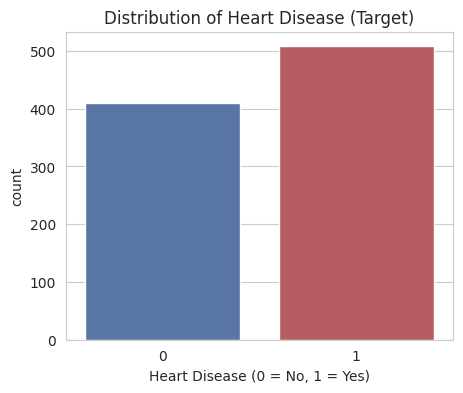

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x="HeartDisease", data=df, palette=["#4C72B0", "#C44E52"])
plt.title("Distribution of Heart Disease (Target)")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.show()

print(df["HeartDisease"].value_counts(normalize=True) * 100)

## Numeric Feature Distributions

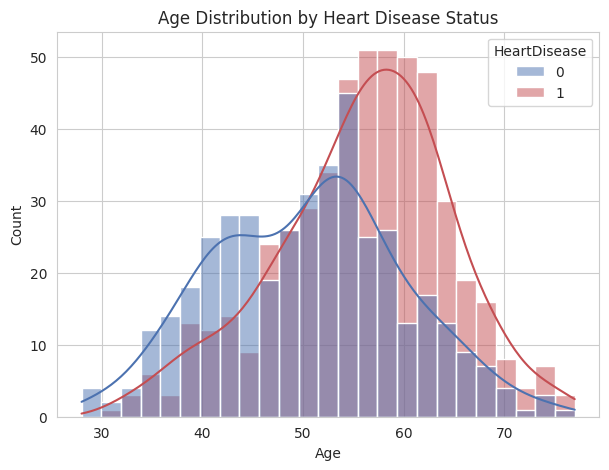

In [7]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="Age", hue="HeartDisease", kde=True, bins=25, palette=["#4C72B0", "#C44E52"])
plt.title("Age Distribution by Heart Disease Status")
plt.show()

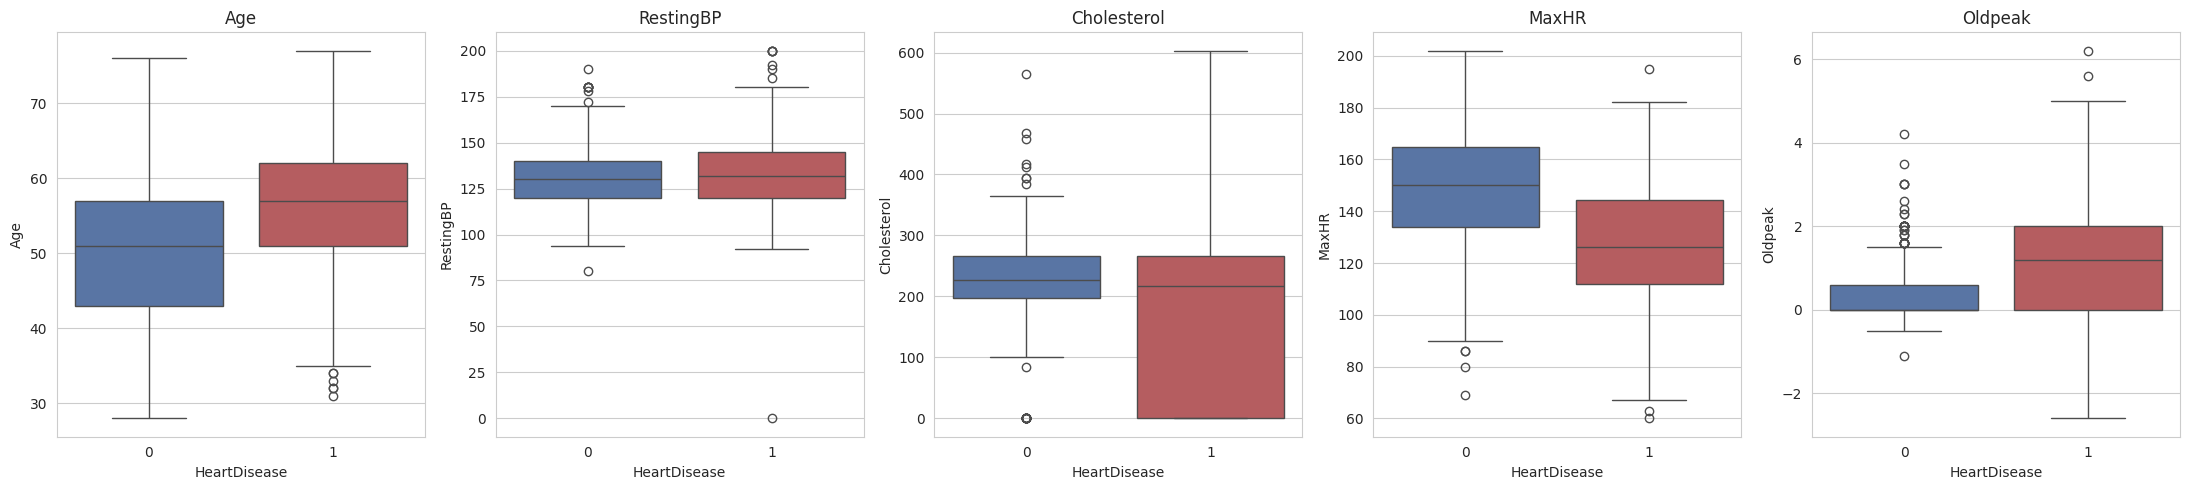

In [8]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="HeartDisease", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Categorical Features vs Target

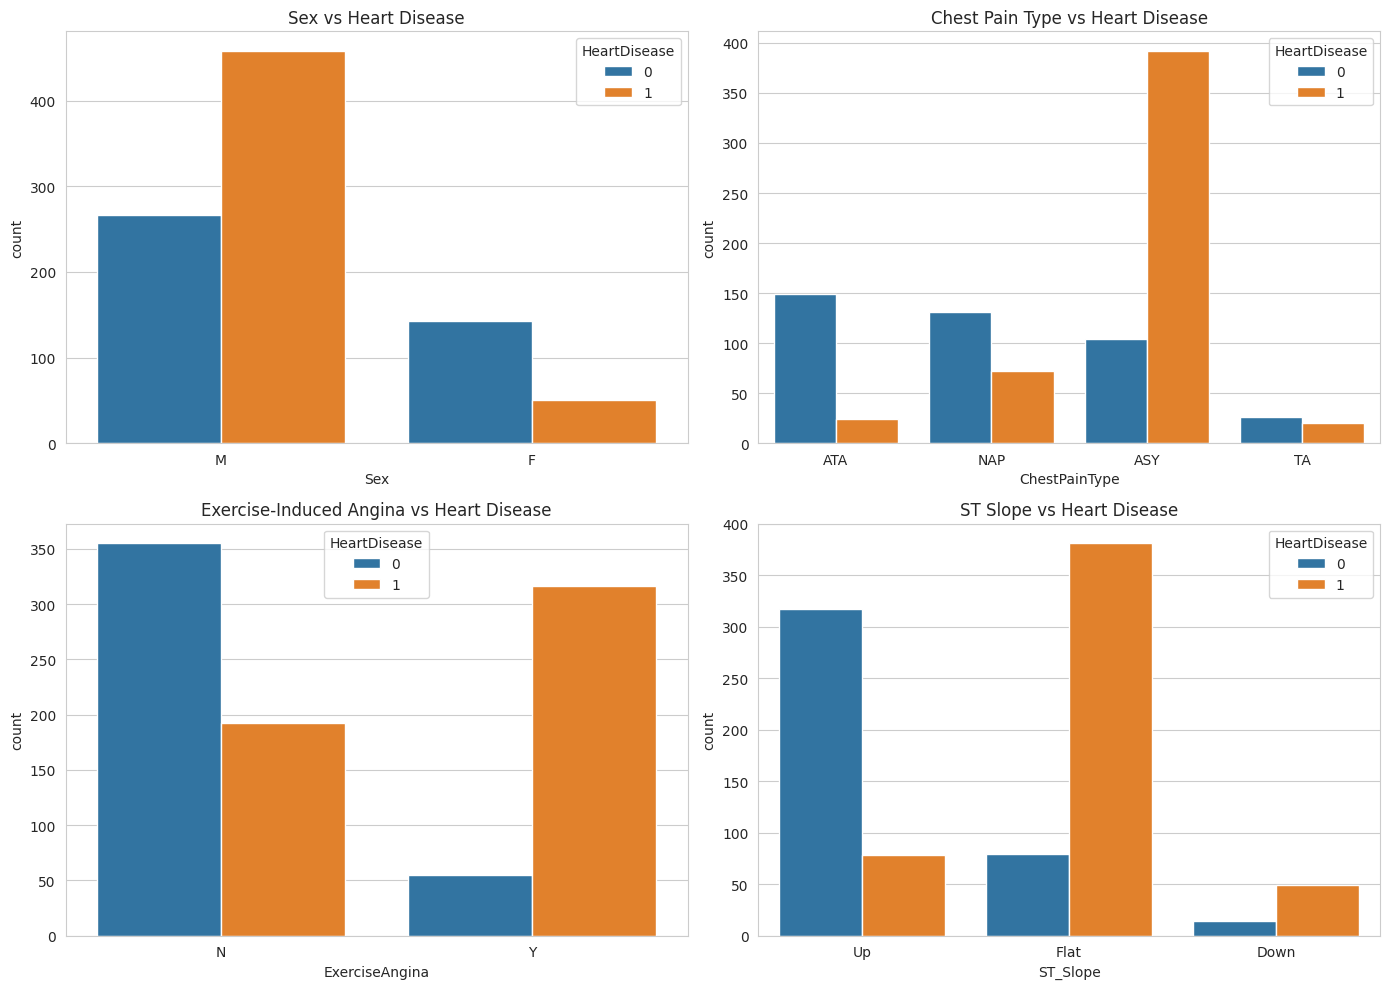

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(x="Sex", hue="HeartDisease", data=df, ax=axes[0, 0]); axes[0, 0].set_title("Sex vs Heart Disease")
sns.countplot(x="ChestPainType", hue="HeartDisease", data=df, ax=axes[0, 1]); axes[0, 1].set_title("Chest Pain Type vs Heart Disease")
sns.countplot(x="ExerciseAngina", hue="HeartDisease", data=df, ax=axes[1, 0]); axes[1, 0].set_title("Exercise-Induced Angina vs Heart Disease")
sns.countplot(x="ST_Slope", hue="HeartDisease", data=df, ax=axes[1, 1]); axes[1, 1].set_title("ST Slope vs Heart Disease")
plt.tight_layout()
plt.show()

## Correlation Heatmap

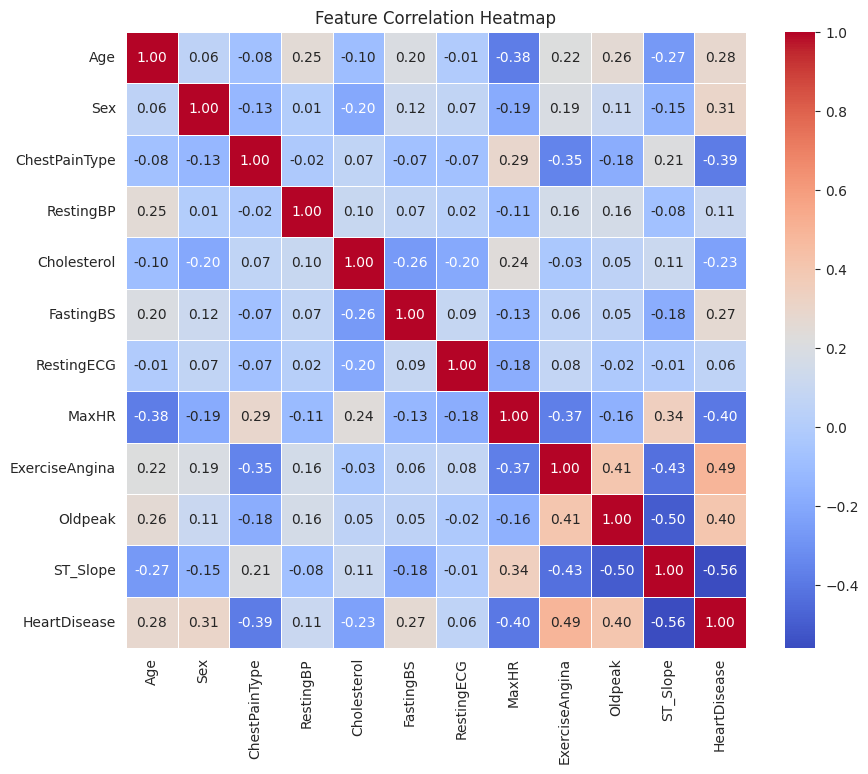

In [10]:
df_encoded = df.copy()
for col in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Key Takeaways

- `ST_Slope`, `ChestPainType`, `ExerciseAngina`, and `Oldpeak` show the strongest visual separation between patients with and without heart disease.
- `Cholesterol` and `RestingBP` contain invalid zero values that need to be treated as missing data before modeling (handled in `model_training.ipynb`).
- The target classes are reasonably balanced, so accuracy is a reasonable primary metric (supplemented with precision/recall/F1).